In [ ]:
# Deep lerning library
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Machine Learning library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn library
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

# Drive library
from google.colab import drive
import os

In [ ]:
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/Colab Notebooks/Original Data'
class_path = os.path.join(file_path, 'train')

classes = sorted(os.listdir(class_path))
print(classes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Black Rot', 'ESCA', 'Healthy', 'Leaf Blight']


In [ ]:
def load_dataset(data_path, tipo):
    import torch
    import torchvision
    import torchvision.transforms as transforms
    transformation = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomVerticalFlip(0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    train_set = torchvision.datasets.ImageFolder(
        root=os.path.join(data_path, 'train' ),
        transform=transformation
    )
    test_set = torchvision.datasets.ImageFolder(
        root=os.path.join(data_path, 'test' ),
        transform=transformation
    )

    train_loader = torch.utils.data.DataLoader(
        train_set,
        batch_size=50,
        num_workers=0,
        shuffle=True
    )

    test_loader = torch.utils.data.DataLoader(
        test_set,
        batch_size=50,
        num_workers=0,
        shuffle=True
    )

    return train_loader, test_loader

train_loader, test_loader = load_dataset(file_path, 'ESCA')
batch_size = train_loader.batch_size

In [ ]:
class Net(nn.Module):

    def __init__(self, num_classes=3):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=12, out_channels=24, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.drop = nn.Dropout2d(p=0.2)
        self.fc = nn.Linear(in_features=32 * 32 * 24, out_features=num_classes)

    def forward(self, x):
        x = F.relu(self.pool(self.conv1(x)))
        x = F.relu(self.pool(self.conv2(x)))
        x = F.dropout(self.drop(x), training=self.training)

        # num_features = x.shape[1] * x.shape[2] * x.shape[3]
        # x = x.view(-1, num_features)

        x = x.view(-1, 32 * 32 * 24)

        x = self.fc(x)
        return torch.log_softmax(x, dim=1)

device = "cpu"
if (torch.cuda.is_available()):
  device = "cuda"

model = Net(num_classes=len(classes)).to(device)

print(model)

Net(
  (conv1): Conv2d(3, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop): Dropout2d(p=0.2, inplace=False)
  (fc): Linear(in_features=24576, out_features=4, bias=True)
)


In [ ]:
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    train_loss = 0
    print("Epoch:", epoch)
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_criteria(output, target)
        train_loss += loss.item()

        loss.backward()
        optimizer.step()

        print('\tTraining batch {} Loss: {:.6f}'.format(batch_idx + 1, loss.item()))

    avg_loss = train_loss / (batch_idx+1)
    print('Training set: Average loss: {:.6f}'.format(avg_loss))
    return avg_loss

In [ ]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        batch_count = 0
        for data, target in test_loader:
            batch_count += 1
            data, target = data.to(device), target.to(device)

            output = model(data)

            test_loss += loss_criteria(output, target).item()

            _, predicted = torch.max(output.data, 1)
            correct += torch.sum(target==predicted).item()

    avg_loss = test_loss / batch_count
    print('Validation set: Average loss: {:.6f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        avg_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

    return avg_loss

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

loss_criteria = nn.CrossEntropyLoss()

epoch_nums = []
training_loss = []
validation_loss = []

epochs = 10
print('Training on', device)
for epoch in range(1, epochs + 1):
        train_loss = train(model, device, train_loader, optimizer, epoch)
        test_loss = test(model, device, test_loader)
        epoch_nums.append(epoch)
        training_loss.append(train_loss)
        validation_loss.append(test_loss)


Training on cuda
Epoch: 1
	Training batch 1 Loss: 1.373952
	Training batch 2 Loss: 5.464727
	Training batch 3 Loss: 11.305834
	Training batch 4 Loss: 6.716350
	Training batch 5 Loss: 1.519524
	Training batch 6 Loss: 1.374319
	Training batch 7 Loss: 1.387112
	Training batch 8 Loss: 1.384663
	Training batch 9 Loss: 1.363149
	Training batch 10 Loss: 1.405062
	Training batch 11 Loss: 1.312018
	Training batch 12 Loss: 1.307459
	Training batch 13 Loss: 1.285476
	Training batch 14 Loss: 1.184801
	Training batch 15 Loss: 1.425964
	Training batch 16 Loss: 1.192764
	Training batch 17 Loss: 1.111762
	Training batch 18 Loss: 1.201329
	Training batch 19 Loss: 1.281361
	Training batch 20 Loss: 1.192543
	Training batch 21 Loss: 1.191744
	Training batch 22 Loss: 1.154629
	Training batch 23 Loss: 1.069204
	Training batch 24 Loss: 1.279987
	Training batch 25 Loss: 1.023057
	Training batch 26 Loss: 1.071263
	Training batch 27 Loss: 1.196315
	Training batch 28 Loss: 1.123303
	Training batch 29 Loss: 1.130

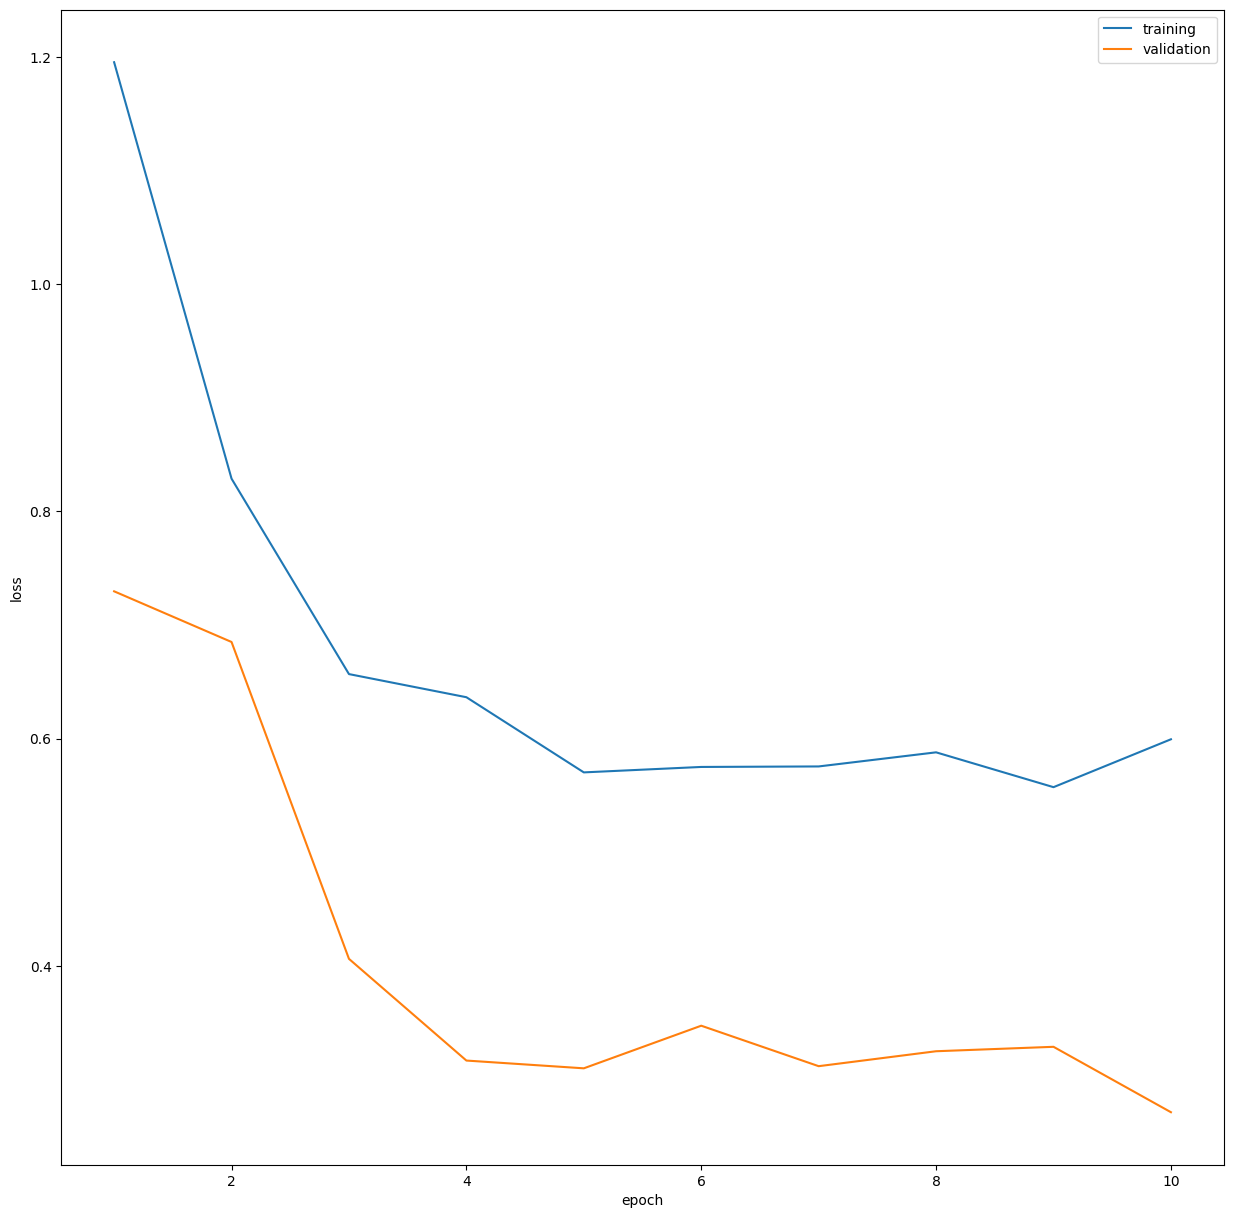

In [ ]:
plt.figure(figsize=(15,15))
plt.plot(epoch_nums, training_loss)
plt.plot(epoch_nums, validation_loss)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['training', 'validation'], loc='upper right')
plt.show()

Getting predictions from test set...


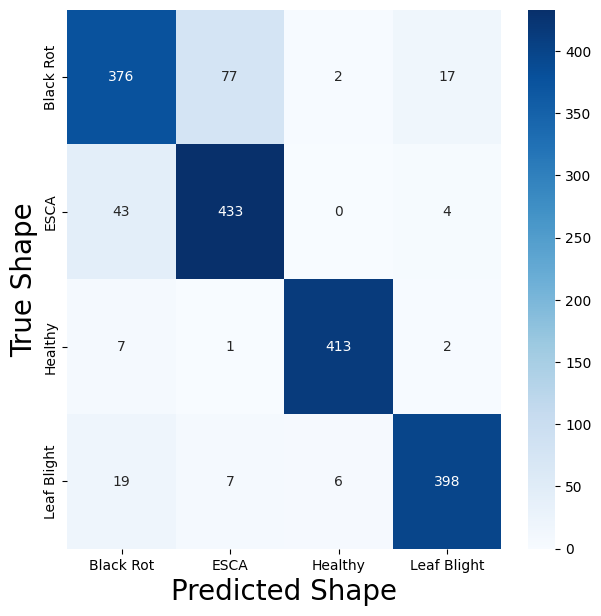

In [ ]:
truelabels = []
predictions = []
model.eval()
print("Getting predictions from test set...")
for data, target in test_loader:
  data = data.to(device)
  for label in target.data.numpy():
    truelabels.append(label)
  for prediction in model(data).data.cpu().numpy().argmax(1):
    predictions.append(prediction)

cm = confusion_matrix(truelabels, predictions)
tick_marks = np.arange(len(classes))

df_cm = pd.DataFrame(cm, index = classes, columns = classes)
plt.figure(figsize = (7,7))
sns.heatmap(df_cm, annot=True, cmap=plt.cm.Blues, fmt='g')
plt.xlabel("Predicted Shape", fontsize = 20)
plt.ylabel("True Shape", fontsize = 20)
plt.show()